# Notebook rendering demo

This notebook exists to show what a published `.ipynb` looks like: prompts, syntax highlighting, stdout, warnings, dataframes and figures. Drop your own notebook in `posts/` and delete this one.

## Setting up

Markdown cells carry the prose, and maths works inline — the spectral gap $\lambda_2 - \lambda_1$ — as well as on its own line:

$$
\mathcal{L} = I - D^{-1/2} A D^{-1/2}
$$


In [1]:
import numpy as np

rng = np.random.default_rng(0)
adjacency = (rng.random((6, 6)) < 0.4).astype(float)
adjacency = np.triu(adjacency, 1)
adjacency += adjacency.T

print(f"edges: {int(adjacency.sum() // 2)}")
print(adjacency.astype(int))

edges: 8
[[0 1 0 0 1 0]
 [1 0 0 1 0 0]
 [0 0 0 1 1 0]
 [0 1 1 0 0 1]
 [1 0 1 0 0 0]
 [0 0 0 1 0 0]]


## Eigenvalues of the Laplacian

The second-smallest eigenvalue is the algebraic connectivity: strictly positive exactly when the graph is connected.

In [2]:
degrees = np.diag(adjacency.sum(axis=1))
laplacian = degrees - adjacency
eigenvalues = np.sort(np.linalg.eigvalsh(laplacian))
eigenvalues.round(3)

array([0.   , 0.519, 1.382, 2.   , 3.618, 4.481])

In [3]:
import pandas as pd

pd.DataFrame({
    "index": range(len(eigenvalues)),
    "eigenvalue": eigenvalues.round(3),
    "connected": eigenvalues > 1e-9,
}).head(4)

,index,eigenvalue,connected
0,0,0.000,False
1,1,0.519,True
2,2,1.382,True
3,3,2.000,True


## Figures

Image outputs are embedded in the notebook file itself, so a published post needs no extra asset handling. The cell below is tagged `hide_input`: the figure is kept and the plotting code is dropped.

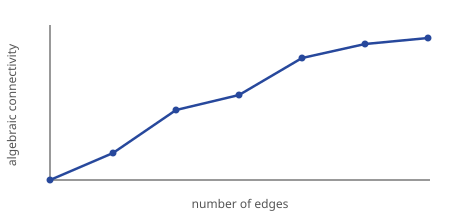

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.5, 2.6))
ax.plot(edge_counts, connectivity, marker="o")
ax.set_xlabel("number of edges")
ax.set_ylabel("algebraic connectivity")
fig.tight_layout()

In [5]:
np.linalg.cond(laplacian)

8.632... 

## What to remember

- the first `# heading` becomes the page title and is not repeated;
- `blog` metadata on the notebook sets tags, summary and date;
- cell tags `hide_input`, `hide_output` and `hide_cell` control what is shown;
- the `.ipynb` itself is published next to the page, so readers can download it.